In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from collections import namedtuple

## van der Pol oscillator

$$
\begin{align}
\frac{\text{d}x}{\text{d}t} &= y\\
\frac{\text{d}y}{\text{d}t} &= \mu (1 - x^2) y -x
\end{align}
$$

In [3]:
## Our model function
def vdp(t, state, model_parameters):
    """ van der Pol oscillator

    Parameters
    ----------

      - t : scalar
        Time point.

      - state : 2-element iterable
        Values of x and y (i.e. van der Pol's variables) at which to evaluate
        the derivatives.

      - model_parameters : collections.namedtuple
        Values of model parameters. For van der Pol model, there's only one
        parameter, mu.

    Returns
    -------

      - 2-element tuple
        Values of the derivatives dx/dt, dy/dt, i.e. the right side of the ODEs.

    """

    x, y = state

    dxdt = y
    dydt = model_parameters.mu * (1 - x**2) * y - x

    return dxdt, dydt

## Model parameters

In [19]:
ParamSet = namedtuple('params', 'mu')

# We can use ParamSet as a function to define a new parameter set. This is
# especially convenient when the model depends on multiple parameters (e.g. in a
# forced van der Pol oscillator).

params = ParamSet(mu = 1)
params.mu

1

In [20]:
state_initial = (1, 0)

t_span = (0, 50) # Stiff Van der Pol oscillator

In [21]:
# check that the model returns adequate output
vdp(0, state_initial, params)

(0, -1)

In [23]:
# estimate the solution of the van der Pol system
# Read docs at https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html

solution = solve_ivp(vdp, t_span, state_initial, args=(params,))

In [24]:
solution

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.990e-04 ...  4.984e+01  5.000e+01]
        y: [[ 1.000e+00  1.000e+00 ... -1.690e+00 -1.577e+00]
            [ 0.000e+00 -9.990e-04 ...  6.642e-01  7.388e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1106
     njev: 0
      nlu: 0

Text(0, 0.5, 'State variable')

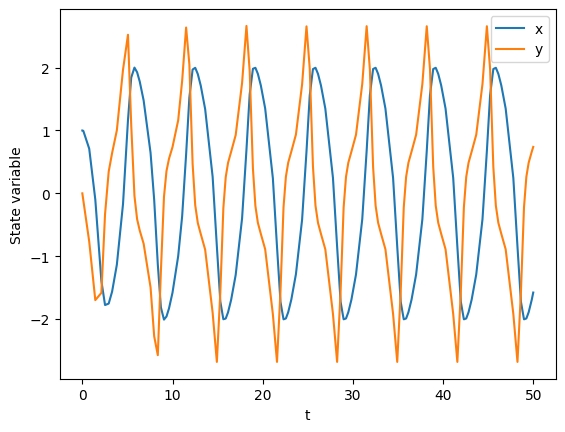

In [27]:
plt.figure()
plt.plot(solution.t, solution.y[0], label='x')
plt.plot(solution.t, solution.y[1], label='y')
plt.legend()
plt.xlabel('t')
plt.ylabel('State variable')